In [18]:
# Read and inspect NPX data from .npy file
from pathlib import Path
import numpy as np

# Try both likely locations depending on notebook working directory
candidates = [
    Path("./Misc/Test_npx/spike_times.npy"),
    Path("./spike_times.npy"),
]

npy_path = next((p for p in candidates if p.exists()), None)
if npy_path is None:
    raise FileNotFoundError(f"Could not find spike_times.npy. Tried: {candidates}")

print(f"File: {npy_path.resolve()}")

arr = np.load(npy_path, allow_pickle=False)

print("\n=== Basic info ===")
print(f"dtype: {arr.dtype}")
print(f"shape: {arr.shape}")
print(f"ndim:  {arr.ndim}")
print(f"size:  {arr.size}")

if arr.size > 0:
    print("\n=== Preview ===")
    preview_n = min(10, arr.size)
    print(f"first {preview_n}: {arr[:preview_n]}")
    print(f"last  {preview_n}: {arr[-preview_n:]}")

    if np.issubdtype(arr.dtype, np.number):
        print("\n=== Numeric summary ===")
        print(f"min:  {arr.min()}")
        print(f"max:  {arr.max()}")
        print(f"mean: {arr.mean()}")
        print(f"std:  {arr.std()}")
        print(f"unique (sample): {np.unique(arr[: min(100000, arr.size)]).shape[0]} in first sample")

File: /home/callum/Keshavarzi-Lab-Workspace/data-conduit/Misc/Test_npx/spike_times.npy

=== Basic info ===
dtype: int64
shape: (11234078,)
ndim:  1
size:  11234078

=== Preview ===
first 10: [12 13 16 28 35 43 43 50 57 61]
last  10: [69902683 69902759 69902764 69902769 69902773 69902776 69902780 69902790
 69902803 69902806]

=== Numeric summary ===
min:  12
max:  69902806
mean: 35191045.85054946
std:  20031682.650971584
unique (sample): 91258 in first sample


shape: (11234078,)
maxval: 69902806
minval: 12


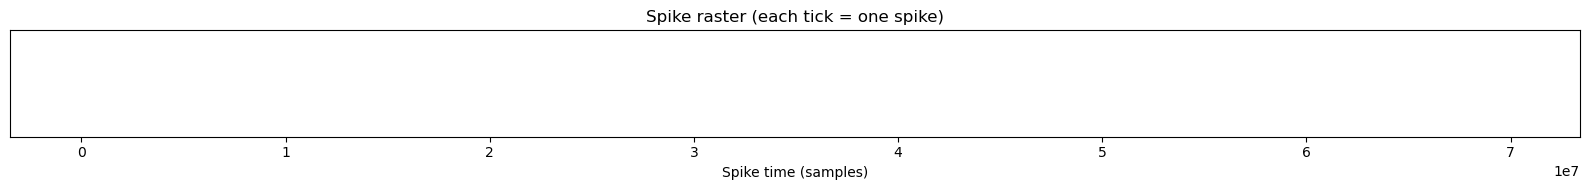

In [19]:
# quick spike raster summary
import matplotlib.pyplot as plt

if 'arr' not in globals():
    raise RuntimeError("Run Cell 1 first to load `arr`.")

print(f"shape: {arr.shape}")
print(f"maxval: {arr.max()}")
print(f"minval: {arr.min()}")

fig, ax = plt.subplots(1, 1, figsize=(16, 2))
ax.scatter(arr, np.ones(arr.size), s=0.5, alpha=0.3, color='black', marker='|')
ax.set_title("Spike raster (each tick = one spike)")
ax.set_xlabel("Spike time (samples)")
ax.set_yticks([])
ax.set_ylim(0.5, 1.5)
plt.tight_layout()
plt.show()

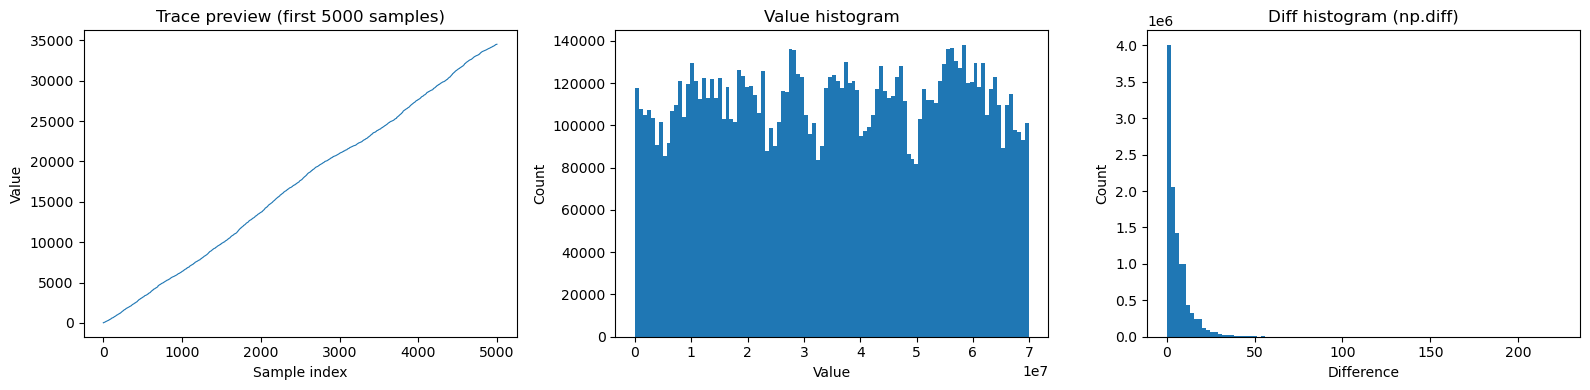

In [20]:
# basic plots
import numpy as np
import matplotlib.pyplot as plt

if 'arr' not in globals():
    raise RuntimeError("Run Cell 1 first to load `arr`.")

if arr.size == 0:
    raise ValueError("Array is empty; nothing to plot.")

# Flatten for generic plotting
x = np.asarray(arr).reshape(-1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1) Trace preview (first N samples)
n_show = min(5000, x.size)
axes[0].plot(np.arange(n_show), x[:n_show], linewidth=0.8)
axes[0].set_title(f"Trace preview (first {n_show} samples)")
axes[0].set_xlabel("Sample index")
axes[0].set_ylabel("Value")

# 2) Value histogram
axes[1].hist(x, bins=100)
axes[1].set_title("Value histogram")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Count")

# 3) Inter-spike-interval-like plot if monotonically non-decreasing
if np.issubdtype(x.dtype, np.number) and x.size > 1 and np.all(np.diff(x) >= 0):
    d = np.diff(x)
    axes[2].hist(d, bins=100)
    axes[2].set_title("Diff histogram (np.diff)")
    axes[2].set_xlabel("Difference")
    axes[2].set_ylabel("Count")
else:
    axes[2].plot(np.sort(x[:n_show]), linewidth=0.8)
    axes[2].set_title("Sorted preview")
    axes[2].set_xlabel("Index")
    axes[2].set_ylabel("Value")

plt.tight_layout()
plt.show()

Residual min/max: 0 / 58668717
Non-zero residual count: 11234076 / 11234078
Non-zero step-error count: 9574890 / 11234077


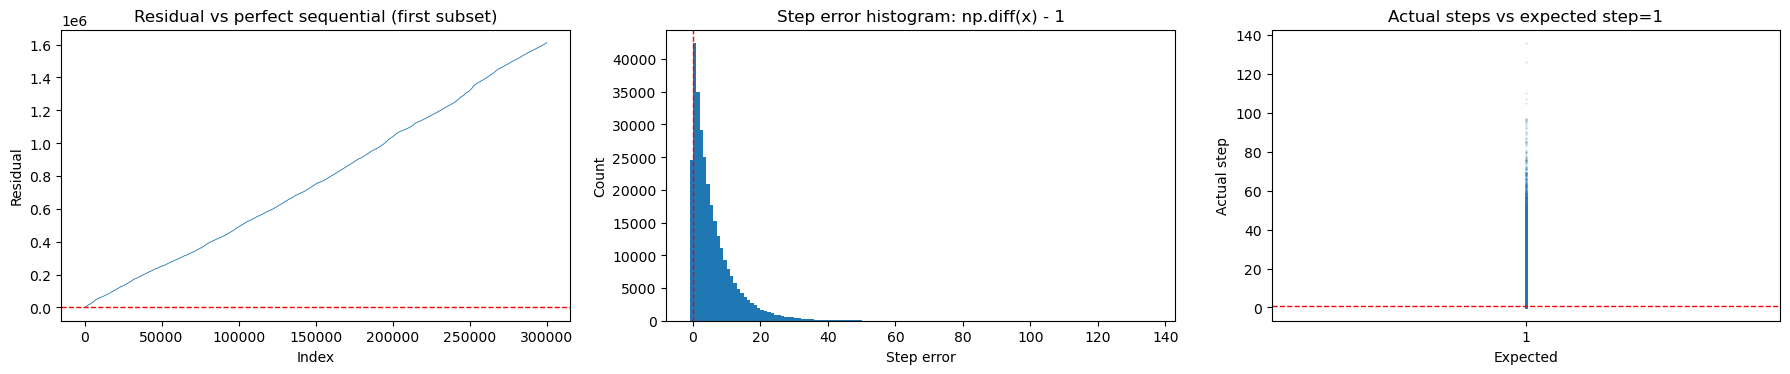

In [21]:
# residual analysis: test against a perfectly sequential series
import numpy as np
import matplotlib.pyplot as plt

if 'arr' not in globals():
    raise RuntimeError("Run Cell 1 first to load `arr`.")

x = np.asarray(arr).reshape(-1)
if x.size < 2:
    raise ValueError("Need at least 2 values for sequential/residual analysis.")

idx = np.arange(x.size, dtype=np.int64)
expected_seq = x[0] + idx
residual = x - expected_seq      # would be all zeros if perfectly sequential
step_error = np.diff(x) - 1      # would be all zeros if every step == 1

print(f"Residual min/max: {residual.min()} / {residual.max()}")
print(f"Non-zero residual count: {(residual != 0).sum()} / {residual.size}")
print(f"Non-zero step-error count: {(step_error != 0).sum()} / {step_error.size}")

# Plot manageable subsets for visibility
n_plot = min(300_000, x.size)
r_plot = residual[:n_plot]
se_plot = step_error[: min(300_000, step_error.size)]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1) residual trace
axes[0].plot(r_plot, linewidth=0.6)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title("Residual vs perfect sequential (first subset)")
axes[0].set_xlabel("Index")
axes[0].set_ylabel("Residual")

# 2) histogram of step errors (diff - 1)
bins = np.arange(se_plot.min(), se_plot.max() + 2) if np.ptp(se_plot) < 200 else 100
axes[1].hist(se_plot, bins=bins)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title("Step error histogram: np.diff(x) - 1")
axes[1].set_xlabel("Step error")
axes[1].set_ylabel("Count")

# 3) QQ-like scatter: actual step vs expected step=1
actual_steps = np.diff(x[:n_plot]).astype(np.int64)
axes[2].scatter(np.ones_like(actual_steps), actual_steps, s=1, alpha=0.1)
axes[2].axhline(1, color='red', linestyle='--', linewidth=1)
axes[2].set_title("Actual steps vs expected step=1")
axes[2].set_xlabel("Expected")
axes[2].set_ylabel("Actual step")
axes[2].set_xticks([1])

plt.tight_layout()
plt.show()

## Full `Test_npx` data audit
This section loads **all** `.npy` and `.tsv` files in `Misc/Test_npx`, prints summary statistics, and generates quick diagnostic visuals for each file.

Using data directory: /home/callum/Keshavarzi-Lab-Workspace/data-conduit/Misc/Test_npx
Discovered files:
- amplitudes.npy
- channel_map.npy
- channel_positions.npy
- spike_clusters.npy
- spike_positions.npy
- spike_templates.npy
- spike_times.npy
- sync_channel.npy
- cluster_Amplitude.tsv
- cluster_group.tsv

=== NPY SUMMARY (standardised fields) ===


,file,kind,dtype,shape,ndim,size,min,q01,median,q99,max,mean,std,monotonic_non_decreasing,sequential_diffs_eq_1
0,amplitudes.npy,npy,float32,"(11234078,)",1,11234078,9.698842,12.560933,1.630340e+01,2.756381e+01,9.638187e+01,1.683317e+01,3.041622e+00,NaN,NaN
1,channel_map.npy,npy,int32,"(383,)",1,383,0.000000,3.820000,1.910000e+02,3.781800e+02,3.820000e+02,1.910000e+02,1.105622e+02,True,True
2,channel_positions.npy,npy,float32,"(383, 2)",2,766,0.000000,0.000000,4.800000e+01,3.747000e+03,3.820000e+03,9.670026e+02,1.226964e+03,NaN,NaN
3,spike_clusters.npy,npy,int32,"(11234078,)",1,11234078,0.000000,1.000000,1.420000e+02,3.260000e+02,3.390000e+02,1.453039e+02,8.327178e+01,False,False
4,spike_positions.npy,npy,float32,"(11234078, 2)",2,22468156,2.102445,10.401873,3.823125e+01,3.429895e+03,3.805716e+03,5.295790e+02,7.312508e+02,NaN,NaN
5,spike_templates.npy,npy,int32,"(11234078,)",1,11234078,0.000000,1.000000,1.420000e+02,3.260000e+02,3.390000e+02,1.453039e+02,8.327178e+01,False,False
6,spike_times.npy,npy,int64,"(11234078,)",1,11234078,12.000000,666570.210000,3.540843e+07,6.912598e+07,6.990281e+07,3.519105e+07,2.003168e+07,True,False
7,sync_channel.npy,npy,int32,"(69902815,)",1,69902815,0.000000,0.000000,0.000000e+00,0.000000e+00,1.000000e+02,2.718059e-05,5.213500e-02,False,False



=== TSV SUMMARY (standardised fields) ===


,file,kind,shape,rows,cols,num_cols,cat_cols,first_num_col,first_num_min,first_num_q01,first_num_median,first_num_q99,first_num_max,first_num_mean,first_num_std
0,cluster_Amplitude.tsv,tsv,"(340, 2)",340,2,2,0,cluster_id,0.0,3.39,169.5,335.61,339.0,169.5,98.149121
1,cluster_group.tsv,tsv,"(340, 2)",340,2,1,1,cluster_id,0.0,3.39,169.5,335.61,339.0,169.5,98.149121


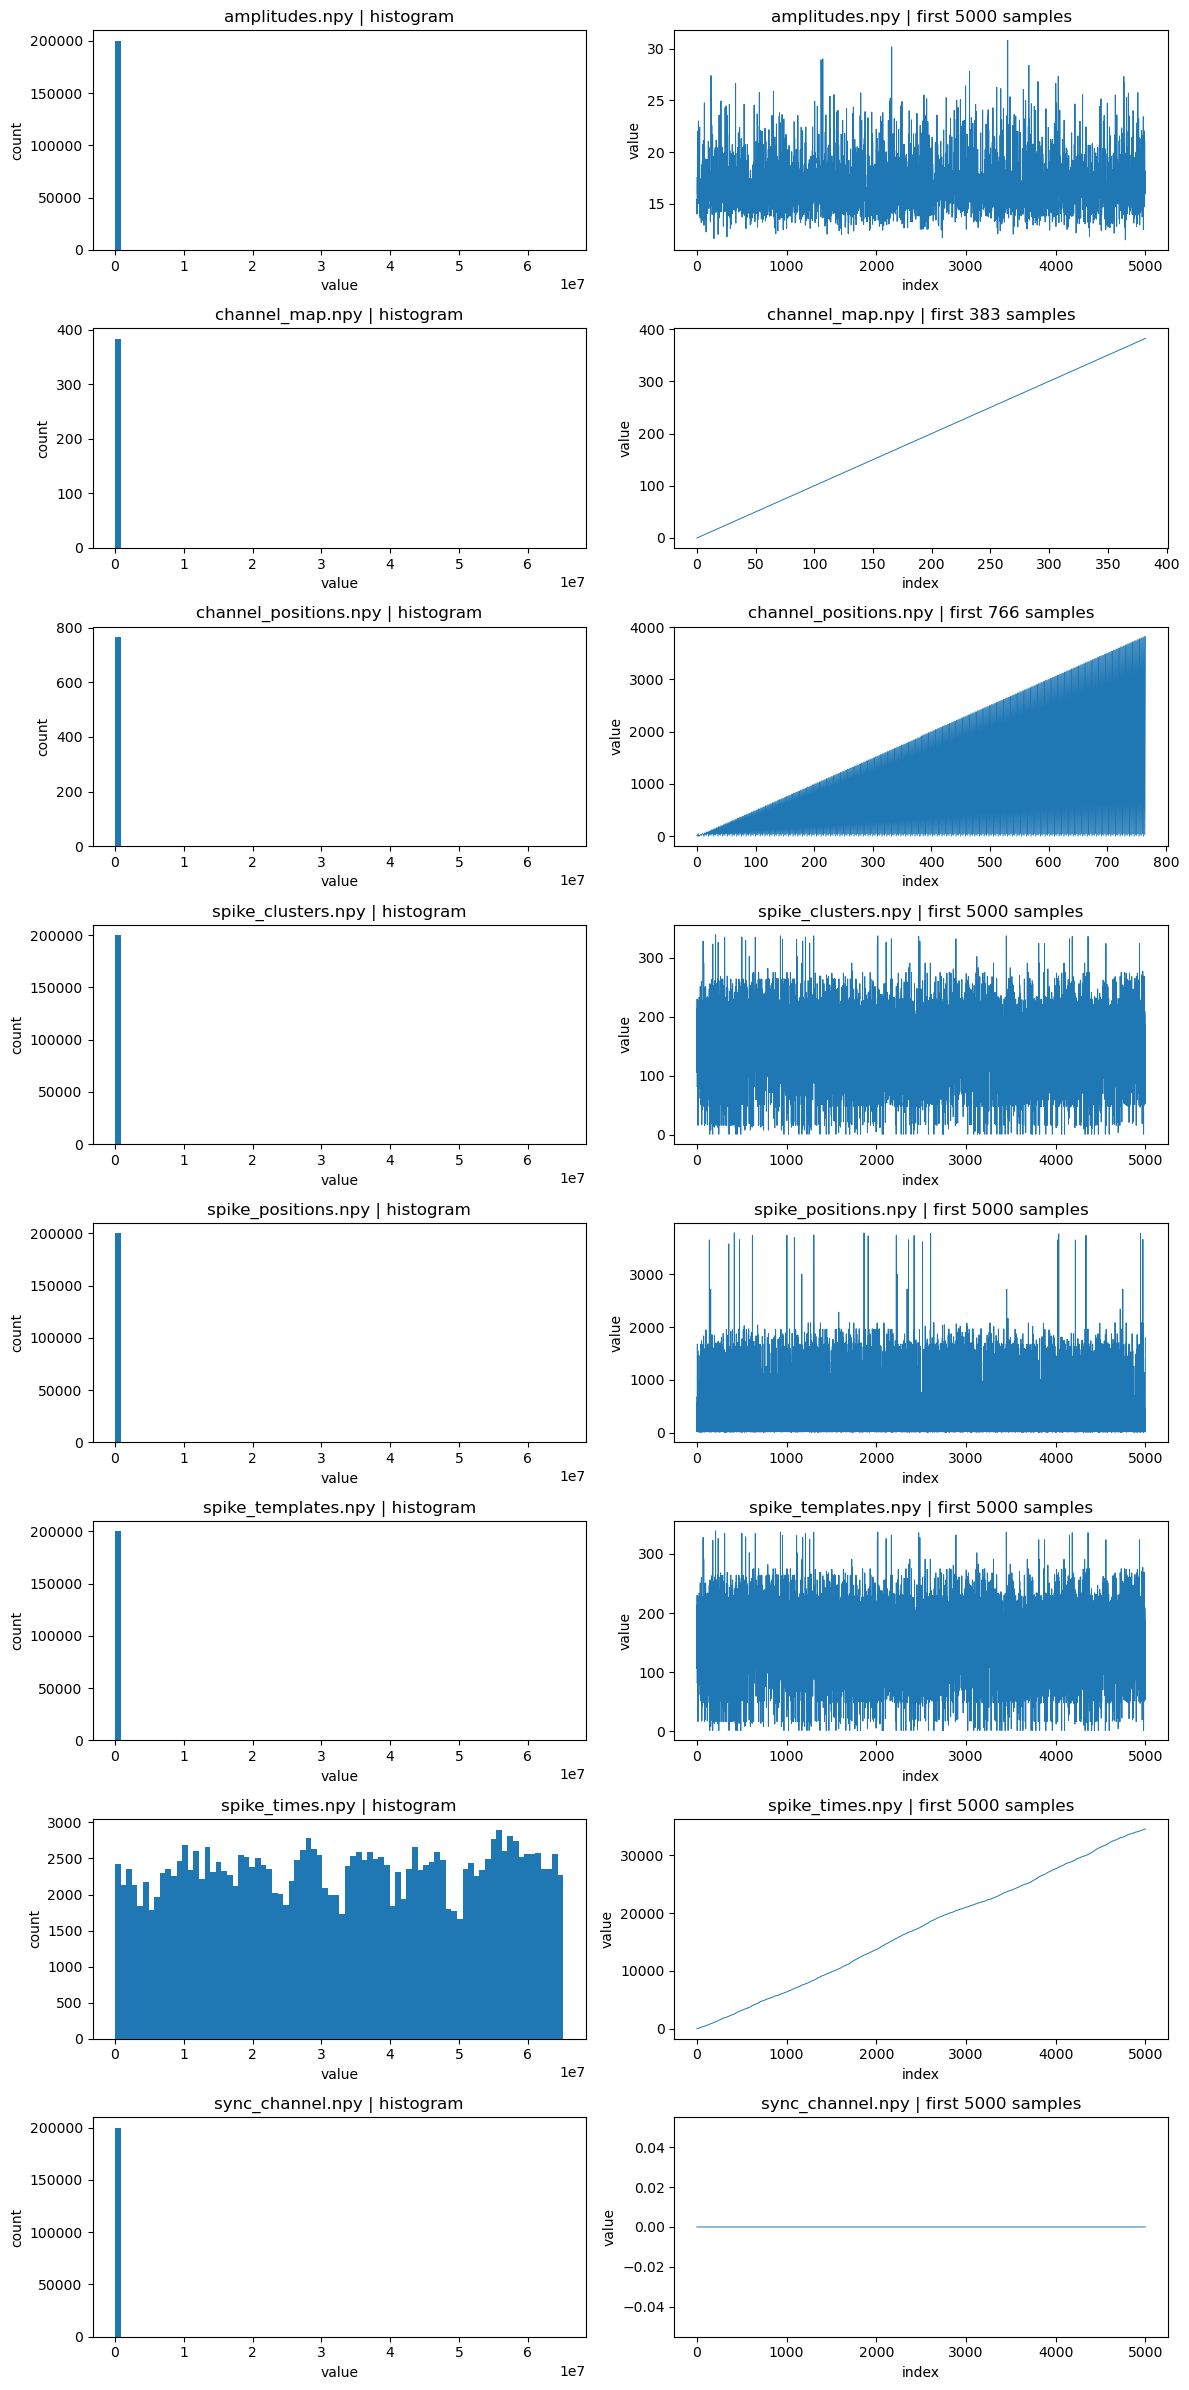

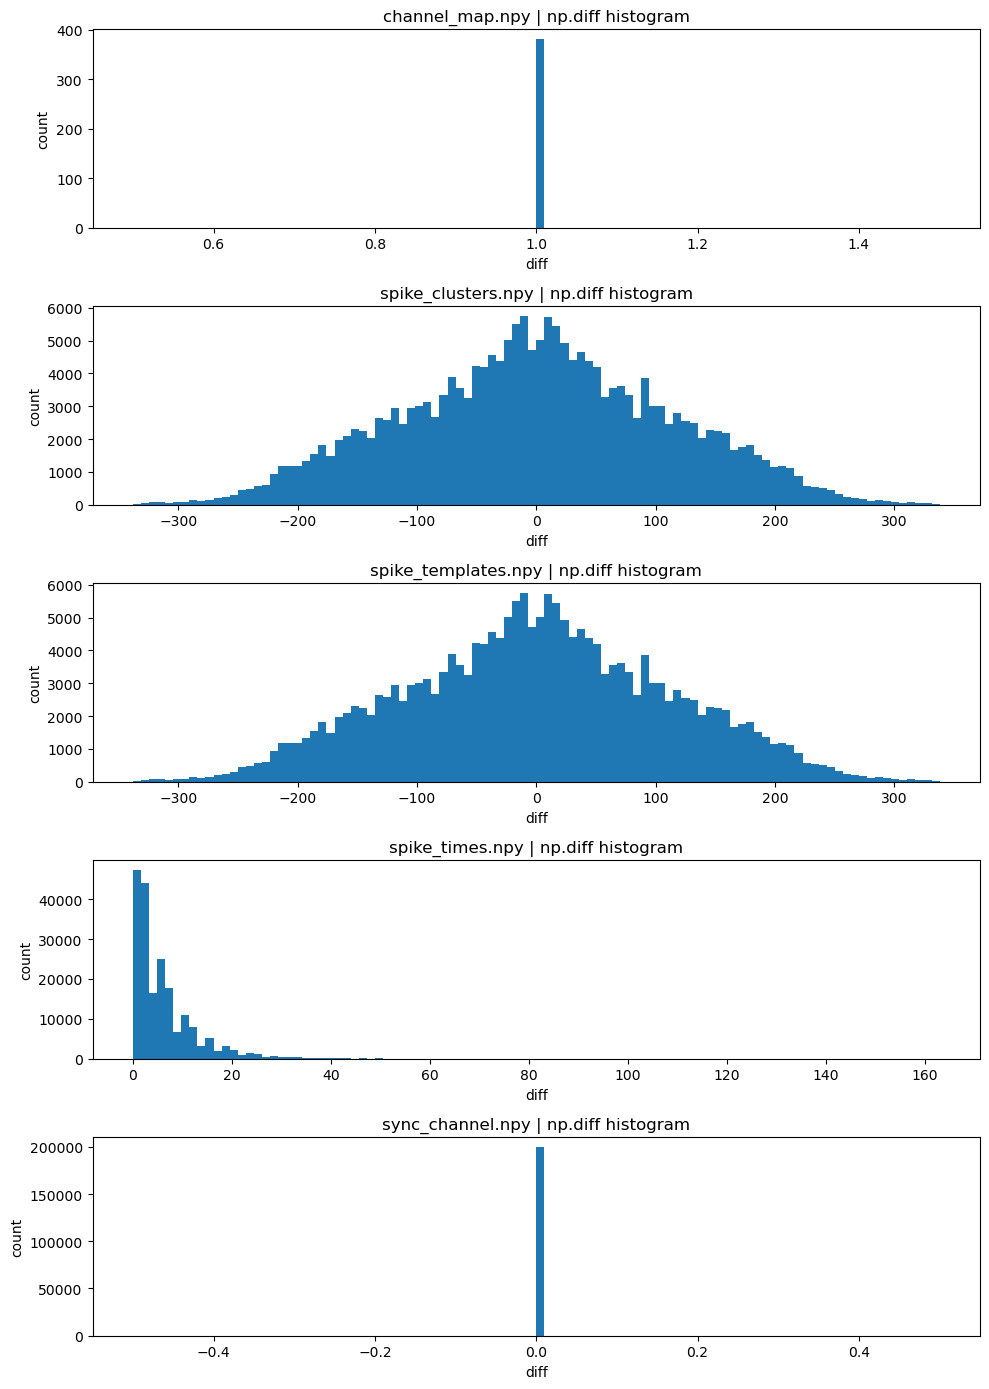

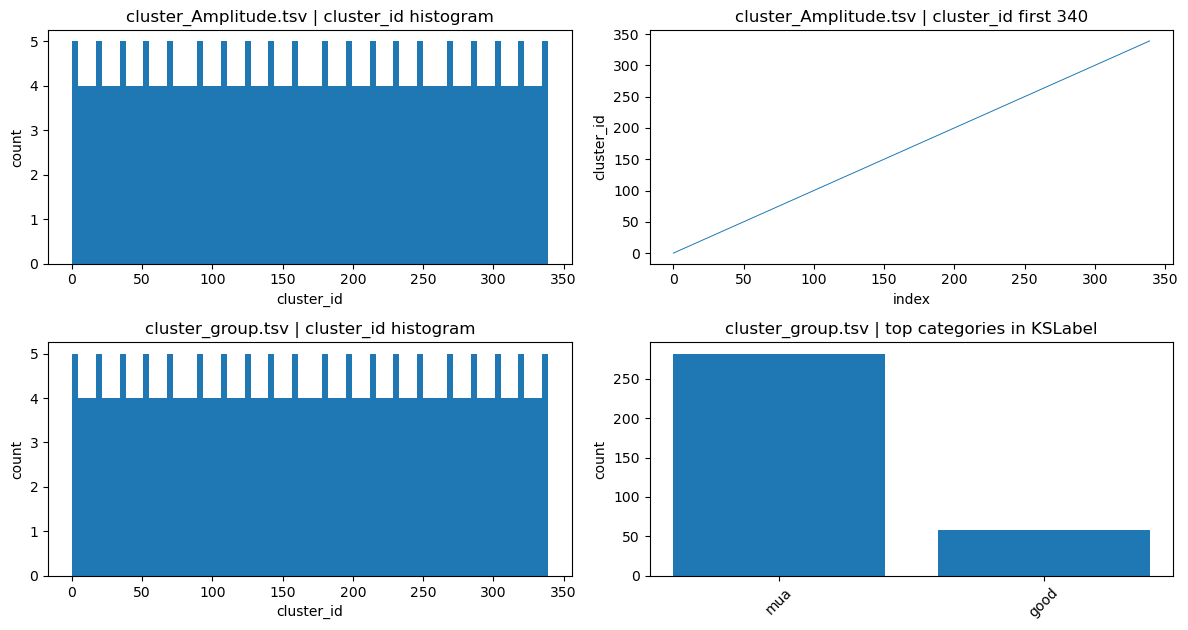


Completed standardised cross-file audit.


In [22]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Resolve folder location robustly
dir_candidates = [
    Path("./Misc/Test_npx"),
    Path("./Test_npx"),
    Path("."),
]
base_dir = next((p for p in dir_candidates if p.exists() and p.is_dir()), None)
if base_dir is None:
    raise FileNotFoundError(f"Could not locate Test_npx directory. Tried: {dir_candidates}")

npy_files = sorted(base_dir.glob("*.npy"))
tsv_files = sorted(base_dir.glob("*.tsv"))
all_files = npy_files + tsv_files

if not all_files:
    raise FileNotFoundError(f"No .npy or .tsv files found in: {base_dir.resolve()}")

print(f"Using data directory: {base_dir.resolve()}")
print("Discovered files:")
for f in all_files:
    print(f"- {f.name}")


def _sample_flat(x, n=200_000):
    flat = np.asarray(x).reshape(-1)
    if flat.size <= n:
        return flat
    idx = np.linspace(0, flat.size - 1, n, dtype=np.int64)
    return flat[idx]


def _nan_if_not(cond, value):
    return value if cond else np.nan


# =====================================================================
# 1) STANDARDISED SUMMARY TABLES (same fields for easy comparison)
# =====================================================================
npy_rows = []
loaded_npy = {}

for p in npy_files:
    arr = np.load(p, allow_pickle=False)
    loaded_npy[p.name] = arr
    flat = arr.reshape(-1)
    is_num = np.issubdtype(arr.dtype, np.number)
    sampled = _sample_flat(arr) if flat.size > 0 else flat

    diffs = np.diff(flat) if (flat.size > 1 and np.issubdtype(arr.dtype, np.integer)) else None
    monotonic_non_decreasing = bool(np.all(diffs >= 0)) if diffs is not None else np.nan
    sequential = bool(np.all(diffs == 1)) if diffs is not None else np.nan

    row = {
        "file": p.name,
        "kind": "npy",
        "dtype": str(arr.dtype),
        "shape": str(arr.shape),
        "ndim": int(arr.ndim),
        "size": int(arr.size),
        "min": _nan_if_not(is_num and flat.size > 0, float(np.min(flat)) if flat.size > 0 else np.nan),
        "q01": _nan_if_not(is_num and sampled.size > 0, float(np.quantile(sampled, 0.01)) if sampled.size > 0 else np.nan),
        "median": _nan_if_not(is_num and sampled.size > 0, float(np.median(sampled)) if sampled.size > 0 else np.nan),
        "q99": _nan_if_not(is_num and sampled.size > 0, float(np.quantile(sampled, 0.99)) if sampled.size > 0 else np.nan),
        "max": _nan_if_not(is_num and flat.size > 0, float(np.max(flat)) if flat.size > 0 else np.nan),
        "mean": _nan_if_not(is_num and flat.size > 0, float(np.mean(flat)) if flat.size > 0 else np.nan),
        "std": _nan_if_not(is_num and flat.size > 0, float(np.std(flat)) if flat.size > 0 else np.nan),
        "monotonic_non_decreasing": monotonic_non_decreasing,
        "sequential_diffs_eq_1": sequential,
    }
    npy_rows.append(row)

tsv_rows = []
loaded_tsv = {}

for p in tsv_files:
    df = pd.read_csv(p, sep="\t")
    loaded_tsv[p.name] = df
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in df.columns if c not in num_cols]

    first_num = num_cols[0] if num_cols else None
    first_num_vals = df[first_num].dropna().to_numpy() if first_num else np.array([])
    sampled = _sample_flat(first_num_vals) if first_num_vals.size > 0 else first_num_vals

    row = {
        "file": p.name,
        "kind": "tsv",
        "shape": str(df.shape),
        "rows": int(df.shape[0]),
        "cols": int(df.shape[1]),
        "num_cols": int(len(num_cols)),
        "cat_cols": int(len(cat_cols)),
        "first_num_col": first_num if first_num else "",
        "first_num_min": float(np.min(first_num_vals)) if first_num_vals.size > 0 else np.nan,
        "first_num_q01": float(np.quantile(sampled, 0.01)) if sampled.size > 0 else np.nan,
        "first_num_median": float(np.median(sampled)) if sampled.size > 0 else np.nan,
        "first_num_q99": float(np.quantile(sampled, 0.99)) if sampled.size > 0 else np.nan,
        "first_num_max": float(np.max(first_num_vals)) if first_num_vals.size > 0 else np.nan,
        "first_num_mean": float(np.mean(first_num_vals)) if first_num_vals.size > 0 else np.nan,
        "first_num_std": float(np.std(first_num_vals)) if first_num_vals.size > 0 else np.nan,
    }
    tsv_rows.append(row)

summary_npy = pd.DataFrame(npy_rows)
summary_tsv = pd.DataFrame(tsv_rows)

print("\n=== NPY SUMMARY (standardised fields) ===")
display(summary_npy)

print("\n=== TSV SUMMARY (standardised fields) ===")
display(summary_tsv)


# =====================================================================
# 2) STANDARDISED VISUALS FOR NPY FILES
#    (same plot types, same layout for all)
# =====================================================================
if loaded_npy:
    # Global x-range for histograms (from pooled sample quantiles)
    pooled = []
    for arr in loaded_npy.values():
        if np.issubdtype(arr.dtype, np.number) and arr.size > 0:
            pooled.append(_sample_flat(arr, n=100_000))
    pooled = np.concatenate(pooled) if pooled else np.array([])

    if pooled.size > 0:
        global_lo = np.quantile(pooled, 0.01)
        global_hi = np.quantile(pooled, 0.99)
        if global_lo == global_hi:
            global_lo, global_hi = pooled.min(), pooled.max()
    else:
        global_lo, global_hi = None, None

    n = len(loaded_npy)
    fig, axes = plt.subplots(n, 2, figsize=(12, 3 * n), squeeze=False)

    for i, (name, arr) in enumerate(loaded_npy.items()):
        flat = arr.reshape(-1)
        is_num = np.issubdtype(arr.dtype, np.number) and flat.size > 0

        # Left: standardized histogram
        if is_num:
            sample = _sample_flat(flat, n=200_000)
            if global_lo is not None and global_hi is not None and global_hi > global_lo:
                sample_clip = sample[(sample >= global_lo) & (sample <= global_hi)]
                axes[i, 0].hist(sample_clip, bins=80, range=(global_lo, global_hi))
            else:
                axes[i, 0].hist(sample, bins=80)
            axes[i, 0].set_title(f"{name} | histogram")
            axes[i, 0].set_xlabel("value")
            axes[i, 0].set_ylabel("count")
        else:
            axes[i, 0].text(0.5, 0.5, "non-numeric or empty", ha="center", va="center")
            axes[i, 0].set_title(f"{name} | histogram")
            axes[i, 0].axis("off")

        # Right: standardized preview trace
        if flat.size > 0:
            n_show = min(5000, flat.size)
            axes[i, 1].plot(np.arange(n_show), flat[:n_show], linewidth=0.7)
            axes[i, 1].set_title(f"{name} | first {n_show} samples")
            axes[i, 1].set_xlabel("index")
            axes[i, 1].set_ylabel("value")
        else:
            axes[i, 1].text(0.5, 0.5, "empty array", ha="center", va="center")
            axes[i, 1].set_title(f"{name} | preview")
            axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

    # Extra standardized diff-hist for integer 1D arrays
    int_1d = {k: v for k, v in loaded_npy.items() if v.ndim == 1 and np.issubdtype(v.dtype, np.integer) and v.size > 1}
    if int_1d:
        m = len(int_1d)
        fig2, axes2 = plt.subplots(m, 1, figsize=(10, 2.8 * m), squeeze=False)
        for j, (name, arr) in enumerate(int_1d.items()):
            diffs = np.diff(arr.reshape(-1))
            d_sample = _sample_flat(diffs, n=200_000)
            axes2[j, 0].hist(d_sample, bins=100)
            axes2[j, 0].set_title(f"{name} | np.diff histogram")
            axes2[j, 0].set_xlabel("diff")
            axes2[j, 0].set_ylabel("count")
        plt.tight_layout()
        plt.show()


# =====================================================================
# 3) STANDARDISED VISUALS FOR TSV FILES
#    (same plot types, same layout for all)
# =====================================================================
if loaded_tsv:
    t = len(loaded_tsv)
    fig3, axes3 = plt.subplots(t, 2, figsize=(12, 3.2 * t), squeeze=False)

    for i, (name, df) in enumerate(loaded_tsv.items()):
        num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        cat_cols = [c for c in df.columns if c not in num_cols]

        # Left: first numeric histogram (standardized choice)
        if num_cols:
            col = num_cols[0]
            vals = df[col].dropna().to_numpy()
            axes3[i, 0].hist(vals, bins=80)
            axes3[i, 0].set_title(f"{name} | {col} histogram")
            axes3[i, 0].set_xlabel(col)
            axes3[i, 0].set_ylabel("count")
        else:
            axes3[i, 0].text(0.5, 0.5, "no numeric columns", ha="center", va="center")
            axes3[i, 0].set_title(f"{name} | numeric histogram")
            axes3[i, 0].axis("off")

        # Right: first categorical top-counts OR first numeric trace
        if cat_cols:
            c = cat_cols[0]
            vc = df[c].astype(str).value_counts().head(15)
            axes3[i, 1].bar(vc.index, vc.values)
            axes3[i, 1].set_title(f"{name} | top categories in {c}")
            axes3[i, 1].tick_params(axis='x', rotation=45)
            axes3[i, 1].set_ylabel("count")
        elif num_cols:
            col = num_cols[0]
            vals = df[col].dropna().to_numpy()
            n_show = min(5000, vals.size)
            axes3[i, 1].plot(np.arange(n_show), vals[:n_show], linewidth=0.7)
            axes3[i, 1].set_title(f"{name} | {col} first {n_show}")
            axes3[i, 1].set_xlabel("index")
            axes3[i, 1].set_ylabel(col)
        else:
            axes3[i, 1].text(0.5, 0.5, "no plottable columns", ha="center", va="center")
            axes3[i, 1].set_title(f"{name} | preview")
            axes3[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

print("\nCompleted standardised cross-file audit.")

(11234078, 2)


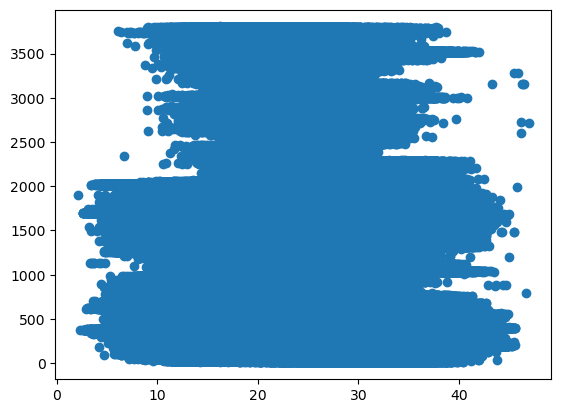

In [41]:
spike_pos = loaded_npy['spike_positions.npy']
print(spike_pos[:].shape)

plt.scatter(spike_pos[:,0], spike_pos[:,1])